In [16]:
#importing Libraries
import os
os.environ["OMP_NUM_THREADS"] = "1"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, classification_report

In [17]:
#Loading Dataset
df = pd.read_csv(r"C:\Users\Aayushi.P.Naik\Desktop\crime_dataset_india.csv")

print(df.head())
print(df.info())


   Report Number   Date Reported Date of Occurrence Time of Occurrence  \
0              1   2/1/2020 0:00      1/1/2020 0:00      1/1/2020 1:11   
1              2  1/1/2020 19:00      1/1/2020 1:00      1/1/2020 6:26   
2              3   2/1/2020 5:00      1/1/2020 2:00     1/1/2020 14:30   
3              4   1/1/2020 5:00      1/1/2020 3:00     1/1/2020 14:46   
4              5  1/1/2020 21:00      1/1/2020 4:00     1/1/2020 16:51   

        City  Crime Code Crime Description  Victim Age Victim Gender  \
0  Ahmedabad         576    IDENTITY THEFT          16             M   
1    Chennai         128          HOMICIDE          37             M   
2   Ludhiana         271        KIDNAPPING          48             F   
3       Pune         170          BURGLARY          49             F   
4       Pune         421         VANDALISM          30             F   

    Weapon Used   Crime Domain  Police Deployed Case Closed  Date Case Closed  
0  Blunt Object  Violent Crime            

In [18]:
#Data Preprocessing

# Remove duplicates
df = df.drop_duplicates()

# Handle missing values
df['Victim Age'] = df['Victim Age'].fillna(df['Victim Age'].median())
df['Weapon Used'] = df['Weapon Used'].fillna("Unknown")
df['Date Case Closed'] = df['Date Case Closed'].fillna("Not Closed")

In [19]:
#Convert Date Columns
df['Date Reported'] = pd.to_datetime(df['Date Reported'], errors='coerce')
df['Date of Occurrence'] = pd.to_datetime(df['Date of Occurrence'], errors='coerce')

In [20]:
#Extract Time Features
df['Year'] = df['Date Reported'].dt.year
df['Month'] = df['Date Reported'].dt.month
df['Day'] = df['Date Reported'].dt.day
df['Hour'] = pd.to_datetime(df['Time of Occurrence'], errors='coerce').dt.hour
print(df.head())

   Report Number       Date Reported  Date of Occurrence Time of Occurrence  \
0              1 2020-02-01 00:00:00 2020-01-01 00:00:00      1/1/2020 1:11   
1              2 2020-01-01 19:00:00 2020-01-01 01:00:00      1/1/2020 6:26   
2              3 2020-02-01 05:00:00 2020-01-01 02:00:00     1/1/2020 14:30   
3              4 2020-01-01 05:00:00 2020-01-01 03:00:00     1/1/2020 14:46   
4              5 2020-01-01 21:00:00 2020-01-01 04:00:00     1/1/2020 16:51   

        City  Crime Code Crime Description  Victim Age Victim Gender  \
0  Ahmedabad         576    IDENTITY THEFT          16             M   
1    Chennai         128          HOMICIDE          37             M   
2   Ludhiana         271        KIDNAPPING          48             F   
3       Pune         170          BURGLARY          49             F   
4       Pune         421         VANDALISM          30             F   

    Weapon Used   Crime Domain  Police Deployed Case Closed  Date Case Closed  \
0  Blunt Ob

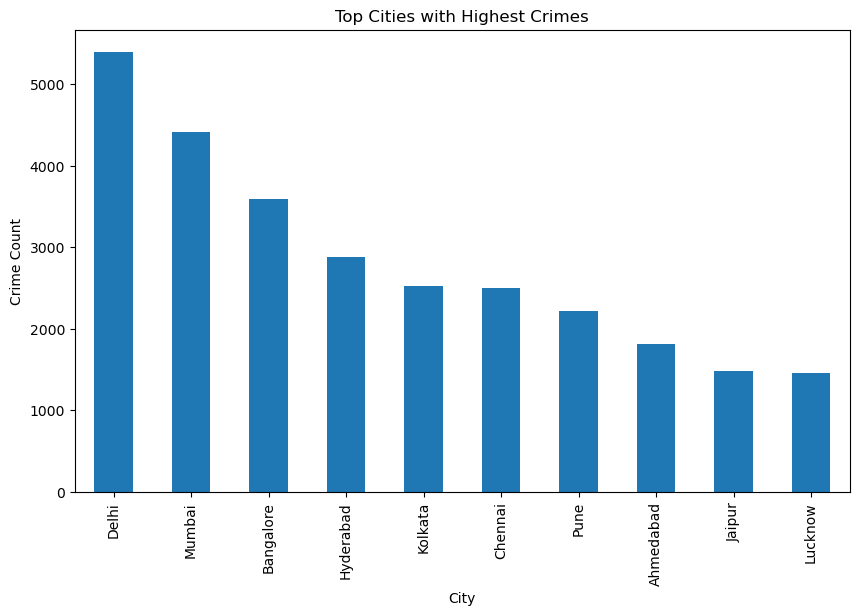

In [21]:
#Exploratory Data Analysis (EDA)
#Crime Distribution by City
plt.figure(figsize=(10,6))
df['City'].value_counts().head(10).plot(kind='bar')
plt.title("Top Cities with Highest Crimes")
plt.xlabel("City")
plt.ylabel("Crime Count")
plt.show()

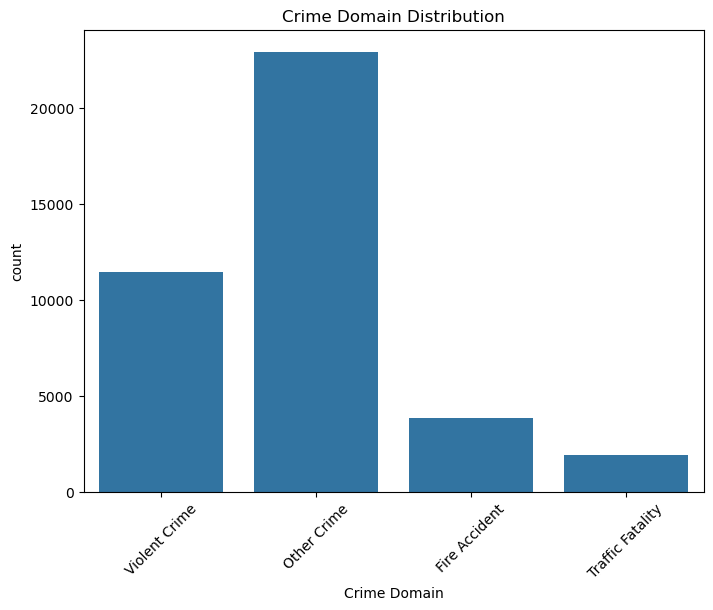

In [22]:
#Crime Domain Distribution
plt.figure(figsize=(8,6))
sns.countplot(x='Crime Domain', data=df)
plt.xticks(rotation=45)
plt.title("Crime Domain Distribution")
plt.show()

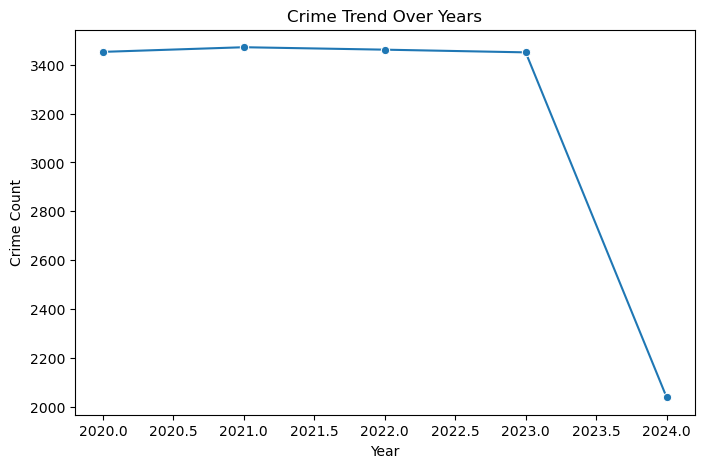

In [23]:
#Crime Distribution Over the Years
yearly_crime = df.groupby('Year').size().reset_index(name='Crime_Count')

plt.figure(figsize=(8,5))

sns.lineplot(data=yearly_crime, x='Year', y='Crime_Count', marker='o')

plt.title("Crime Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Crime Count")

plt.show()

In [24]:
#Encoding Categorical Variables
label_encoder = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = label_encoder.fit_transform(df[col].astype(str))

In [25]:
#Machine Learning Model (Classification)
#Define Features and Target
X = df.drop(['Crime Domain','Date Reported','Date of Occurrence','Date Case Closed'], axis=1)
y = df['Crime Domain']

In [26]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [27]:
#Train ML Model (Random Forest)
model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("Model trained successfully")

Model trained successfully


In [28]:
#Evaluate Model
accuracy = accuracy_score(y_test, predictions)

print("Model Accuracy:", accuracy)

print(classification_report(y_test, predictions))

Model Accuracy: 0.8952938247011952
              precision    recall  f1-score   support

           0       1.00      0.55      0.71       737
           1       0.84      1.00      0.92      4580
           2       1.00      0.70      0.83       393
           3       1.00      0.83      0.91      2322

    accuracy                           0.90      8032
   macro avg       0.96      0.77      0.84      8032
weighted avg       0.91      0.90      0.89      8032



In [29]:
#Crime Hotspot Detection (Clustering)
city_crime = df.groupby('City').size().reset_index(name='Crime_Count')

kmeans = KMeans(n_clusters=5, random_state=42)

city_crime['Cluster'] = kmeans.fit_predict(city_crime[['Crime_Count']])

print(city_crime.head())


   City  Crime_Count  Cluster
0     0          764        4
1     1         1817        0
2     2         3588        2
3     3          690        4
4     4         2493        0


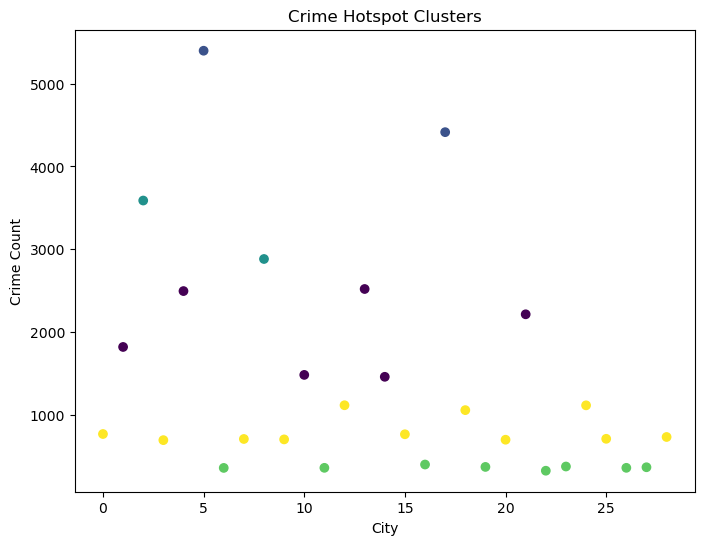

In [30]:
#Crime Hotspot Visualization
plt.figure(figsize=(8,6))

plt.scatter(city_crime['City'], city_crime['Crime_Count'],
            c=city_crime['Cluster'], cmap='viridis')

plt.xlabel("City")
plt.ylabel("Crime Count")
plt.title("Crime Hotspot Clusters")

plt.show()